In [1]:
# ============================================================
# BÀI 2 - PHÂN LỚP
# DATASET: DIABETES 130-US HOSPITALS
# TARGET: readmitted
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Đọc dữ liệu đã tiền xử lý ở Bài 1
data_path = "../data/processed/diabetes_processed.csv"

diabetes = pd.read_csv(data_path)

print("=== THÔNG TIN DATASET ===")
print("Kích thước:", diabetes.shape)
print("Số bản ghi:", diabetes.shape[0])
print("Số thuộc tính:", diabetes.shape[1])

print("\n=== TARGET: readmitted ===")
print(diabetes["readmitted"].value_counts())

print("\nTỷ lệ (%):")
print(
    diabetes["readmitted"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

diabetes.head()


=== THÔNG TIN DATASET ===
Kích thước: (101766, 46)
Số bản ghi: 101766
Số thuộc tính: 46

=== TARGET: readmitted ===
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Tỷ lệ (%):
readmitted
NO     53.91
>30    34.93
<30    11.16
Name: proportion, dtype: float64


,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,8222157,Caucasian,Female,[0-10),6,25,1,1,Unknown,Pediatrics-Endocrinology,...,No,No,No,No,No,No,No,No,No,NO
1,55629189,Caucasian,Female,[10-20),1,1,7,3,Unknown,Unknown,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,Unknown,Unknown,...,No,No,No,No,No,No,No,No,Yes,NO
3,82442376,Caucasian,Male,[30-40),1,1,7,2,Unknown,Unknown,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,42519267,Caucasian,Male,[40-50),1,1,7,1,Unknown,Unknown,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [2]:
# ============================================================
# BƯỚC 2 - CHUẨN BỊ FEATURES (X) VÀ TARGET (y)
# ============================================================

# Target cần dự đoán
y = diabetes["readmitted"].copy()

# Features
X = diabetes.drop(
    columns=[
        "readmitted",   # target
        "patient_nbr"   # mã định danh bệnh nhân
    ]
).copy()

# Xác định thuộc tính số và thuộc tính phân loại
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(exclude=np.number).columns.tolist()

print("=== CHUẨN BỊ X VÀ y ===")
print("Kích thước X:", X.shape)
print("Kích thước y:", y.shape)

print("\nSố thuộc tính dạng số:", len(numeric_cols))
print("Số thuộc tính phân loại:", len(categorical_cols))

print("\nThuộc tính dạng số:")
print(numeric_cols)

print("\nThuộc tính phân loại:")
print(categorical_cols)

=== CHUẨN BỊ X VÀ y ===
Kích thước X: (101766, 44)
Kích thước y: (101766,)

Số thuộc tính dạng số: 11
Số thuộc tính phân loại: 33

Thuộc tính dạng số:
['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

Thuộc tính phân loại:
['race', 'gender', 'age', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']


In [3]:
# ============================================================
# BƯỚC 3 - CHIA TRAIN / TEST
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,       # 20% dùng để test
    random_state=42,     # giúp kết quả có thể tái lập
    stratify=y           # giữ tỷ lệ các lớp
)

print("=== KÍCH THƯỚC TRAIN / TEST ===")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\n=== TỶ LỆ TARGET TRONG TRAIN (%) ===")
print(
    y_train.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\n=== TỶ LỆ TARGET TRONG TEST (%) ===")
print(
    y_test.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

=== KÍCH THƯỚC TRAIN / TEST ===
X_train: (81412, 44)
X_test : (20354, 44)
y_train: (81412,)
y_test : (20354,)

=== TỶ LỆ TARGET TRONG TRAIN (%) ===
readmitted
NO     53.91
>30    34.93
<30    11.16
Name: proportion, dtype: float64

=== TỶ LỆ TARGET TRONG TEST (%) ===
readmitted
NO     53.91
>30    34.93
<30    11.16
Name: proportion, dtype: float64


In [4]:
# ============================================================
# BƯỚC 4 - TẠO BỘ TIỀN XỬ LÝ CHO MÔ HÌNH
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Numerical: chuẩn hóa về cùng thang đo
numeric_transformer = StandardScaler()

# Categorical: chuyển thành các cột 0/1
categorical_transformer = OneHotEncoder(
    handle_unknown="ignore"
)

# Kết hợp 2 kiểu xử lý
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

print("=== BỘ TIỀN XỬ LÝ ===")
print("Thuộc tính số:", len(numeric_cols))
print("Thuộc tính phân loại:", len(categorical_cols))
print("Đã tạo preprocessor thành công!")

=== BỘ TIỀN XỬ LÝ ===
Thuộc tính số: 11
Thuộc tính phân loại: 33
Đã tạo preprocessor thành công!


In [5]:
# ============================================================
# BƯỚC 5 - MÔ HÌNH 1: LOGISTIC REGRESSION
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Pipeline: tiền xử lý -> Logistic Regression
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

print("Đang huấn luyện Logistic Regression...")

# Huấn luyện
logistic_model.fit(X_train, y_train)

# Dự đoán
y_pred_logistic = logistic_model.predict(X_test)

print("Huấn luyện hoàn tất!")


# ============================================================
# ĐÁNH GIÁ
# ============================================================

accuracy_logistic = accuracy_score(
    y_test, y_pred_logistic
)

precision_logistic = precision_score(
    y_test,
    y_pred_logistic,
    average="weighted",
    zero_division=0
)

recall_logistic = recall_score(
    y_test,
    y_pred_logistic,
    average="weighted",
    zero_division=0
)

f1_logistic = f1_score(
    y_test,
    y_pred_logistic,
    average="weighted",
    zero_division=0
)

print("\n=== LOGISTIC REGRESSION ===")
print("Accuracy :", round(accuracy_logistic, 4))
print("Precision:", round(precision_logistic, 4))
print("Recall   :", round(recall_logistic, 4))
print("F1-score :", round(f1_logistic, 4))

print("\n=== CLASSIFICATION REPORT ===")
print(
    classification_report(
        y_test,
        y_pred_logistic,
        zero_division=0
    )
)

Đang huấn luyện Logistic Regression...
Huấn luyện hoàn tất!

=== LOGISTIC REGRESSION ===
Accuracy : 0.5774
Precision: 0.5369
Recall   : 0.5774
F1-score : 0.527

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

         <30       0.33      0.02      0.04      2272
         >30       0.50      0.34      0.41      7109
          NO       0.61      0.84      0.71     10973

    accuracy                           0.58     20354
   macro avg       0.48      0.40      0.39     20354
weighted avg       0.54      0.58      0.53     20354



In [6]:
# ============================================================
# BƯỚC 6 - MÔ HÌNH 2: DECISION TREE
# ============================================================

from sklearn.tree import DecisionTreeClassifier

# Pipeline: tiền xử lý -> Decision Tree
tree_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        max_depth=10,
        random_state=42,
        class_weight="balanced"
    ))
])

print("Đang huấn luyện Decision Tree...")

# Huấn luyện
tree_model.fit(X_train, y_train)

# Dự đoán
y_pred_tree = tree_model.predict(X_test)

print("Huấn luyện hoàn tất!")


# ============================================================
# ĐÁNH GIÁ
# ============================================================

accuracy_tree = accuracy_score(y_test, y_pred_tree)

precision_tree = precision_score(
    y_test,
    y_pred_tree,
    average="weighted",
    zero_division=0
)

recall_tree = recall_score(
    y_test,
    y_pred_tree,
    average="weighted",
    zero_division=0
)

f1_tree = f1_score(
    y_test,
    y_pred_tree,
    average="weighted",
    zero_division=0
)

print("\n=== DECISION TREE ===")
print("Accuracy :", round(accuracy_tree, 4))
print("Precision:", round(precision_tree, 4))
print("Recall   :", round(recall_tree, 4))
print("F1-score :", round(f1_tree, 4))

print("\n=== CLASSIFICATION REPORT ===")
print(
    classification_report(
        y_test,
        y_pred_tree,
        zero_division=0
    )
)

Đang huấn luyện Decision Tree...
Huấn luyện hoàn tất!

=== DECISION TREE ===
Accuracy : 0.4913
Precision: 0.5321
Recall   : 0.4913
F1-score : 0.506

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

         <30       0.20      0.40      0.27      2272
         >30       0.43      0.38      0.40      7109
          NO       0.66      0.58      0.62     10973

    accuracy                           0.49     20354
   macro avg       0.43      0.45      0.43     20354
weighted avg       0.53      0.49      0.51     20354



In [7]:
# ============================================================
# BƯỚC 7 - MÔ HÌNH 3: RANDOM FOREST
# ============================================================

from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

print("Đang huấn luyện Random Forest...")

# Huấn luyện
random_forest_model.fit(X_train, y_train)

# Dự đoán
y_pred_rf = random_forest_model.predict(X_test)

print("Huấn luyện hoàn tất!")


# ============================================================
# ĐÁNH GIÁ
# ============================================================

accuracy_rf = accuracy_score(y_test, y_pred_rf)

precision_rf = precision_score(
    y_test,
    y_pred_rf,
    average="weighted",
    zero_division=0
)

recall_rf = recall_score(
    y_test,
    y_pred_rf,
    average="weighted",
    zero_division=0
)

f1_rf = f1_score(
    y_test,
    y_pred_rf,
    average="weighted",
    zero_division=0
)

print("\n=== RANDOM FOREST ===")
print("Accuracy :", round(accuracy_rf, 4))
print("Precision:", round(precision_rf, 4))
print("Recall   :", round(recall_rf, 4))
print("F1-score :", round(f1_rf, 4))

print("\n=== CLASSIFICATION REPORT ===")
print(
    classification_report(
        y_test,
        y_pred_rf,
        zero_division=0
    )
)

Đang huấn luyện Random Forest...
Huấn luyện hoàn tất!

=== RANDOM FOREST ===
Accuracy : 0.4892
Precision: 0.5428
Recall   : 0.4892
F1-score : 0.5055

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

         <30       0.18      0.43      0.25      2272
         >30       0.47      0.33      0.39      7109
          NO       0.67      0.61      0.63     10973

    accuracy                           0.49     20354
   macro avg       0.44      0.45      0.42     20354
weighted avg       0.54      0.49      0.51     20354



=== SO SÁNH 3 MÔ HÌNH ===


,Mô hình,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.5774,0.5369,0.5774,0.5270
1,Decision Tree,0.4913,0.5321,0.4913,0.5060
2,Random Forest,0.4892,0.5428,0.4892,0.5055


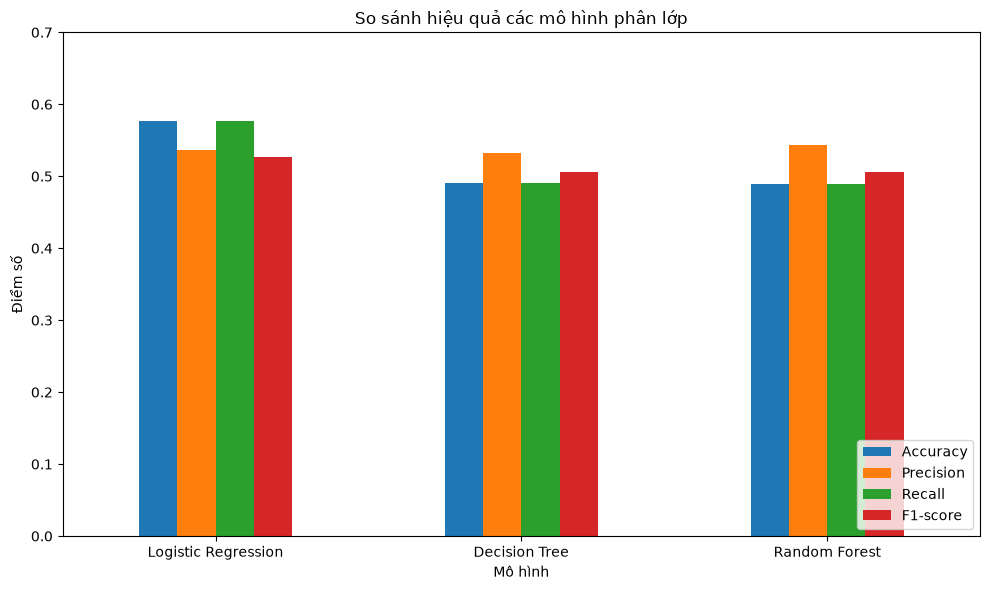

In [8]:
# ============================================================
# BƯỚC 8 - SO SÁNH 3 MÔ HÌNH
# ============================================================

results = pd.DataFrame({
    "Mô hình": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_logistic,
        accuracy_tree,
        accuracy_rf
    ],
    "Precision": [
        precision_logistic,
        precision_tree,
        precision_rf
    ],
    "Recall": [
        recall_logistic,
        recall_tree,
        recall_rf
    ],
    "F1-score": [
        f1_logistic,
        f1_tree,
        f1_rf
    ]
})

# Làm tròn
results.iloc[:, 1:] = results.iloc[:, 1:].round(4)

print("=== SO SÁNH 3 MÔ HÌNH ===")
display(results)

# Biểu đồ so sánh
results.set_index("Mô hình").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("So sánh hiệu quả các mô hình phân lớp")
plt.ylabel("Điểm số")
plt.xlabel("Mô hình")
plt.ylim(0, 0.7)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


=== CONFUSION MATRIX - LOGISTIC REGRESSION ===
[[9256 1675   42]
 [4599 2444   66]
 [1417  802   53]]


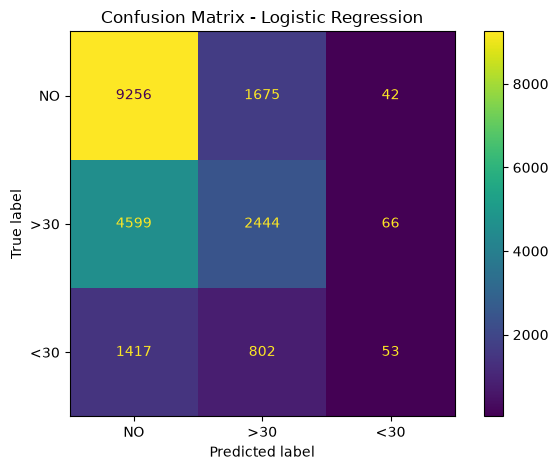


=== CONFUSION MATRIX - DECISION TREE ===
[[6398 2807 1768]
 [2575 2696 1838]
 [ 656  711  905]]


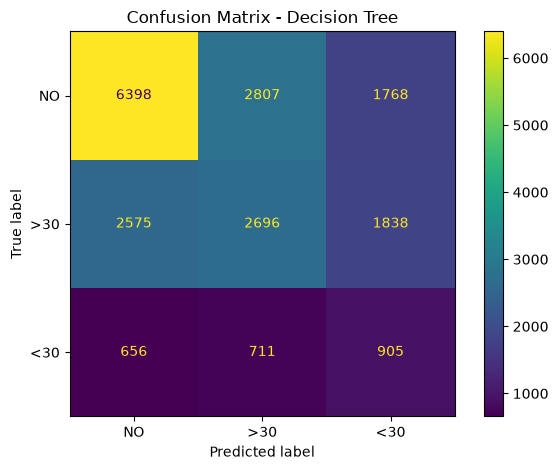


=== CONFUSION MATRIX - RANDOM FOREST ===
[[6643 2081 2249]
 [2610 2347 2152]
 [ 716  588  968]]


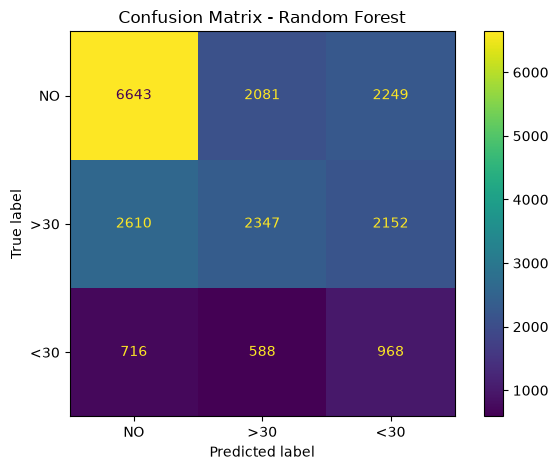

In [9]:
# ============================================================
# BƯỚC 9 - CONFUSION MATRIX CHO 3 MÔ HÌNH
# ============================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

labels = ["NO", ">30", "<30"]

models_predictions = {
    "Logistic Regression": y_pred_logistic,
    "Decision Tree": y_pred_tree,
    "Random Forest": y_pred_rf
}

for model_name, prediction in models_predictions.items():

    cm = confusion_matrix(
        y_test,
        prediction,
        labels=labels
    )

    print(f"\n=== CONFUSION MATRIX - {model_name.upper()} ===")
    print(cm)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=labels
    )

    disp.plot(values_format="d")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()
    plt.show()

In [10]:
# ============================================================
# BƯỚC 10 - ROC-AUC ĐA LỚP
# ============================================================

from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

# Thứ tự lớp cố định
classes = ["NO", ">30", "<30"]

# Chuyển y_test thành dạng nhị phân cho bài toán đa lớp
y_test_bin = label_binarize(y_test, classes=classes)

# Xác suất dự đoán của từng mô hình
y_prob_logistic = logistic_model.predict_proba(X_test)
y_prob_tree = tree_model.predict_proba(X_test)
y_prob_rf = random_forest_model.predict_proba(X_test)

# predict_proba trả cột theo thứ tự classes_ của từng classifier.
# Sắp xếp lại để khớp với: NO, >30, <30
def reorder_probabilities(model, probabilities, target_classes):
    model_classes = model.named_steps["classifier"].classes_
    indices = [list(model_classes).index(c) for c in target_classes]
    return probabilities[:, indices]

y_prob_logistic = reorder_probabilities(
    logistic_model, y_prob_logistic, classes
)

y_prob_tree = reorder_probabilities(
    tree_model, y_prob_tree, classes
)

y_prob_rf = reorder_probabilities(
    random_forest_model, y_prob_rf, classes
)

# Tính ROC-AUC theo One-vs-Rest
auc_logistic = roc_auc_score(
    y_test_bin,
    y_prob_logistic,
    average="macro",
    multi_class="ovr"
)

auc_tree = roc_auc_score(
    y_test_bin,
    y_prob_tree,
    average="macro",
    multi_class="ovr"
)

auc_rf = roc_auc_score(
    y_test_bin,
    y_prob_rf,
    average="macro",
    multi_class="ovr"
)

print("=== ROC-AUC (MACRO, ONE-VS-REST) ===")
print("Logistic Regression:", round(auc_logistic, 4))
print("Decision Tree      :", round(auc_tree, 4))
print("Random Forest      :", round(auc_rf, 4))

=== ROC-AUC (MACRO, ONE-VS-REST) ===
Logistic Regression: 0.649
Decision Tree      : 0.6396
Random Forest      : 0.6553


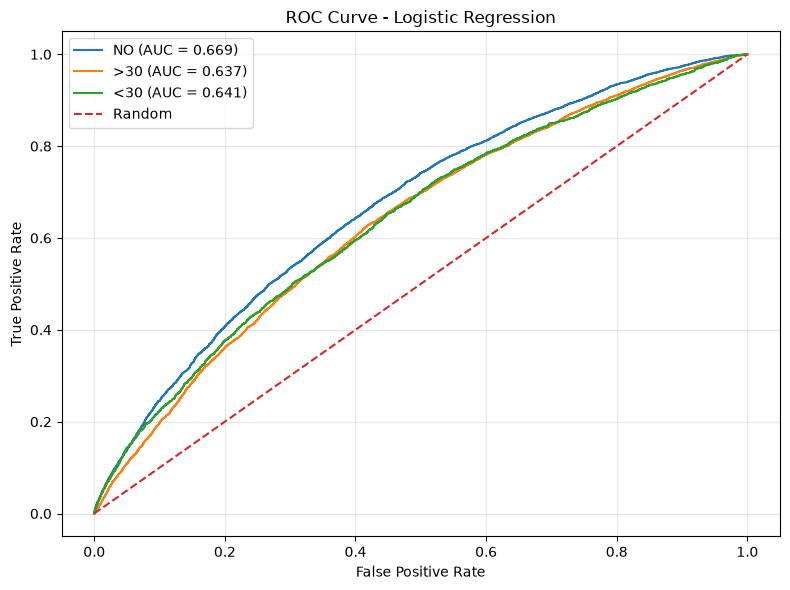

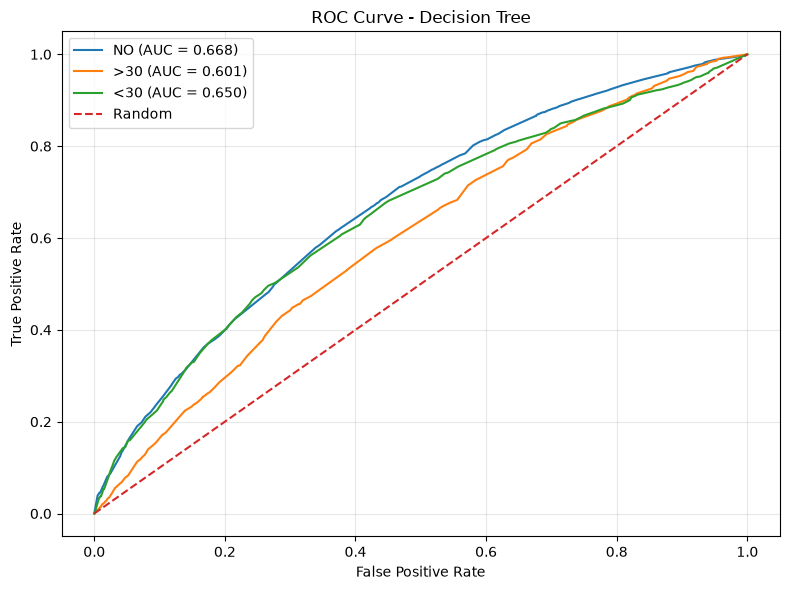

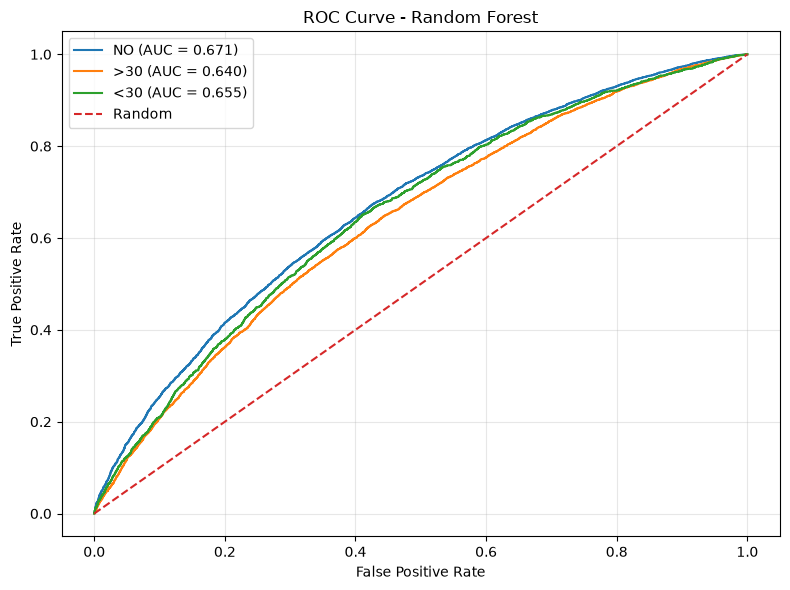

In [11]:
# ============================================================
# VẼ ROC CURVE CHO 3 MÔ HÌNH
# ============================================================

from sklearn.metrics import roc_curve, auc

models_prob = {
    "Logistic Regression": y_prob_logistic,
    "Decision Tree": y_prob_tree,
    "Random Forest": y_prob_rf
}

for model_name, y_prob in models_prob.items():

    plt.figure(figsize=(8, 6))

    for i, class_name in enumerate(classes):

        fpr, tpr, _ = roc_curve(
            y_test_bin[:, i],
            y_prob[:, i]
        )

        class_auc = auc(fpr, tpr)

        plt.plot(
            fpr,
            tpr,
            label=f"{class_name} (AUC = {class_auc:.3f})"
        )

    # Đường tham chiếu ngẫu nhiên
    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Random"
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {model_name}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [12]:
# ============================================================
# BƯỚC 11 - CẢI THIỆN LOGISTIC REGRESSION
# XỬ LÝ MẤT CÂN BẰNG BẰNG CLASS_WEIGHT
# ============================================================

logistic_balanced = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

print("Đang huấn luyện Logistic Regression (Balanced)...")

logistic_balanced.fit(X_train, y_train)

y_pred_logistic_balanced = logistic_balanced.predict(X_test)

print("Huấn luyện hoàn tất!")

# Đánh giá
accuracy_log_bal = accuracy_score(
    y_test, y_pred_logistic_balanced
)

precision_log_bal = precision_score(
    y_test,
    y_pred_logistic_balanced,
    average="weighted",
    zero_division=0
)

recall_log_bal = recall_score(
    y_test,
    y_pred_logistic_balanced,
    average="weighted",
    zero_division=0
)

f1_log_bal = f1_score(
    y_test,
    y_pred_logistic_balanced,
    average="weighted",
    zero_division=0
)

print("\n=== LOGISTIC REGRESSION - BALANCED ===")
print("Accuracy :", round(accuracy_log_bal, 4))
print("Precision:", round(precision_log_bal, 4))
print("Recall   :", round(recall_log_bal, 4))
print("F1-score :", round(f1_log_bal, 4))

print("\n=== CLASSIFICATION REPORT ===")
print(
    classification_report(
        y_test,
        y_pred_logistic_balanced,
        zero_division=0
    )
)

Đang huấn luyện Logistic Regression (Balanced)...
Huấn luyện hoàn tất!

=== LOGISTIC REGRESSION - BALANCED ===
Accuracy : 0.4787
Precision: 0.5371
Recall   : 0.4787
F1-score : 0.4993

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

         <30       0.18      0.41      0.25      2272
         >30       0.45      0.39      0.42      7109
          NO       0.67      0.55      0.60     10973

    accuracy                           0.48     20354
   macro avg       0.43      0.45      0.42     20354
weighted avg       0.54      0.48      0.50     20354



In [13]:
# ============================================================
# BƯỚC 12 - SO SÁNH TRƯỚC VÀ SAU KHI XỬ LÝ MẤT CÂN BẰNG
# ============================================================

comparison_balance = pd.DataFrame({
    "Mô hình": [
        "Logistic Regression",
        "Logistic Regression - Balanced"
    ],
    "Accuracy": [
        accuracy_logistic,
        accuracy_log_bal
    ],
    "Precision": [
        precision_logistic,
        precision_log_bal
    ],
    "Recall": [
        recall_logistic,
        recall_log_bal
    ],
    "F1-score": [
        f1_logistic,
        f1_log_bal
    ]
})

comparison_balance.iloc[:, 1:] = (
    comparison_balance.iloc[:, 1:].round(4)
)

print("=== SO SÁNH TRƯỚC / SAU CÂN BẰNG ===")
display(comparison_balance)

# Recall riêng của lớp <30
recall_minority_before = recall_score(
    y_test,
    y_pred_logistic,
    labels=["<30"],
    average=None
)[0]

recall_minority_after = recall_score(
    y_test,
    y_pred_logistic_balanced,
    labels=["<30"],
    average=None
)[0]

print("\n=== KHẢ NĂNG NHẬN DIỆN LỚP <30 ===")
print(
    "Recall trước cân bằng:",
    round(recall_minority_before, 4)
)

print(
    "Recall sau cân bằng  :",
    round(recall_minority_after, 4)
)

=== SO SÁNH TRƯỚC / SAU CÂN BẰNG ===


,Mô hình,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.5774,0.5369,0.5774,0.5270
1,Logistic Regression - Balanced,0.4787,0.5371,0.4787,0.4993



=== KHẢ NĂNG NHẬN DIỆN LỚP <30 ===
Recall trước cân bằng: 0.0233
Recall sau cân bằng  : 0.4058


## Kết luận Bài 2 – Phân lớp

Trong bài thực hành, bộ dữ liệu Diabetes 130-US Hospitals được sử dụng để xây dựng mô hình dự đoán thuộc tính `readmitted` với ba lớp `NO`, `>30` và `<30`.

Dữ liệu được chia theo tỷ lệ 80% huấn luyện và 20% kiểm thử bằng phương pháp stratified split nhằm duy trì tỷ lệ các lớp. Các thuộc tính số được chuẩn hóa bằng StandardScaler, trong khi các thuộc tính phân loại được mã hóa bằng One-Hot Encoding.

Ba thuật toán phân lớp được thử nghiệm gồm Logistic Regression, Decision Tree và Random Forest.

### Kết quả
- Logistic Regression đạt Accuracy 57,74% và F1-score 52,70%.
- Decision Tree đạt Accuracy 49,13% và F1-score 50,60%.
- Random Forest đạt Accuracy 48,92% và F1-score 50,55%.
- ROC-AUC macro lần lượt là 0,6490; 0,6396 và 0,6553.

Dữ liệu có hiện tượng mất cân bằng lớp, trong đó lớp `<30` chỉ chiếm khoảng 11,16%. Logistic Regression ban đầu chỉ đạt Recall 2,33% đối với lớp này.

Sau khi áp dụng `class_weight="balanced"`, Recall của lớp `<30` tăng từ 2,33% lên 40,58%. Tuy nhiên Accuracy tổng thể giảm từ 57,74% xuống 47,87%. Điều này cho thấy việc xử lý mất cân bằng giúp mô hình nhận diện lớp thiểu số tốt hơn nhưng tạo ra sự đánh đổi về hiệu quả dự đoán tổng thể.

Nhìn chung, không nên chỉ dựa vào Accuracy khi đánh giá bài toán có dữ liệu mất cân bằng. Cần xem xét đồng thời Precision, Recall, F1-score, Confusion Matrix và ROC-AUC.